# Customer Churn Analysis & Intervention Strategy
### Telco Customer Dataset

In my previous work, retaining customers was something I was genuinely good at. I wanted to see if data could confirm what I already believed intuitively, and where it would surprise me.

This project uses the Telco dataset to answer two questions I actually cared about: what really drives churn and can a model catch it before it happens?

The short answer: yes. But the interesting part is how.

---

## Results at a glance

| Metric | Value |
|--------|-------|
| Model AUC | 84% |
| Churners identified | 95% (vs 56% at default threshold) |
| Potential savings | $658K (test set, 1,409 customers) |



> **Why AUC and not accuracy?** The dataset is imbalanced, 73% of customers didn't churn. 
> A model that just predicts "no churn" for everyone would hit 73% accuracy without learning anything useful. 
> AUC measures how well the model *ranks* churners above non-churners, regardless of the threshold. 
> 84% means if you pick one churner and one non-churner at random, the model ranks the churner as higher risk 84% of the time.

---

*Full analysis below.*

### Style + Imports

### Setup

I built a custom colour palette for all charts based on Sinn.'s brand guidelines.
Sinn. is my design and analytics practice. Consistency in visualisation was important 
to me, every chart in this notebook follows the same style so the reader isn't 
distracted by formatting changes.

In [71]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Color palette 
COLORS = {
    'ink': '#0F1117',
    'primary': '#1B5FA8',
    'secondary': '#5B9BD5',
    'light': '#B8CEEA',
    'gray': '#6B7280',
    'background': '#F5F6F8',
}

# Chart styling
plt.rcParams['figure.facecolor'] = COLORS['background']
plt.rcParams['axes.facecolor'] = COLORS['background']
plt.rcParams['axes.edgecolor'] = COLORS['gray']
plt.rcParams['axes.labelcolor'] = COLORS['ink']
plt.rcParams['text.color'] = COLORS['ink']
plt.rcParams['xtick.color'] = COLORS['gray']
plt.rcParams['ytick.color'] = COLORS['gray']
plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica Neue', 'Arial', 'sans-serif']
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

### Data Loading

7,043 customers, 21 features. The dataset covers demographics, account information, 
and services each customer has signed up for. I loaded it directly from GitHub 
so the notebook is fully reproducible, no local file dependencies.

In [72]:
# Load data from GitHub (reproducible)
url = "https://raw.githubusercontent.com/ChiragSomashekar/customer-churn-ml-pipeline/main/data/telco_churn.csv"
df = pd.read_csv(url)

print(f"Dataset: {df.shape[0]:,} customers, {df.shape[1]} features")
df.head()

Dataset: 7,043 customers, 21 features


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 1: Business Framing

Most churn models stop at prediction. I wanted to go further, if we can predict 
who's leaving, what's that actually worth to the business and what should we do about it?

First thing I checked: how bad is the churn problem actually?

In [73]:
# Quick look at the target variable 
print("Churn distribution:")
print(df['Churn'].value_counts(normalize=True).round(3))

Churn distribution:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


26.5% of customers churned. 
That's roughly 1 in 4 customers walking out. In my experience, that's the kind of number that should make a retention team very uncomfortable.

In [74]:
# Business cost estimation
avg_monthly_revenue = df['MonthlyCharges'].mean()
avg_tenure = df['tenure'].mean()

print(f"Average monthly revenue per customer: ${avg_monthly_revenue:.2f}")
print(f"Average customer tenure: {avg_tenure:.1f} months")

# Estimated CLV (customer lifetime value)
avg_lifetime_value = avg_monthly_revenue * avg_tenure
print(f"Rough Customer Lifetime Value: ${avg_lifetime_value:.2f}")

# Cost of Churn
churned_customers = df['Churn'].value_counts()['Yes']
print(f"\nChurned customers in dataset: {churned_customers}")
print(f"Estimated revenue lost to churn: ${churned_customers * avg_monthly_revenue:.2f}/month")

Average monthly revenue per customer: $64.76
Average customer tenure: 32.4 months
Rough Customer Lifetime Value: $2096.41

Churned customers in dataset: 1869
Estimated revenue lost to churn: $121039.60/month


$121K in monthly revenue lost. That's where the $121K number comes from, 1,869 churned customers at an average of $64.76/month each.

The customer lifetime value of ~$2,100 is what made me set the cost of a missed churner at $2,100 in the intervention model later. If you can save a customer who was about to leave, that's roughly what you're preserving.

## The Business Case

Retaining a customer costs a fraction of acquiring a new one. At $315 acquisition cost ([Deloitte via GrowSurf](https://growsurf.com/statistics/customer-acquisition-cost-statistics/)) and $2,100 lifetime value, even a $100 retention offer makes sense if it saves the customer. That's the logic behind every intervention decision in this notebook.

The model needs to do three things: predict who's leaving, explain why and help 
prioritise who to act on first.

## Data Overview

Standard first checks: shape, column types, missing values. 
Nothing surprising here, the dataset is clean.

In [75]:
# Data overview
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (7043, 21)

Column types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract          

## Data Quality Check

One thing jumped out immediately, `TotalCharges` is stored as an object instead of a number. That usually means there are empty strings hiding in the data.

In [76]:
# How many values can't be converted to numeric?
print(f"Non-numeric values in TotalCharges: {pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()}")

Non-numeric values in TotalCharges: 11


In [77]:
# Investigate: who are these 11 rows?
empty_charges = df[df['TotalCharges'].str.strip() == '']
print(f"Total rows with empty TotalCharges: {len(empty_charges)}")
print(f"Of those, rows with tenure = 0: {(empty_charges['tenure'] == 0).sum()}")

Total rows with empty TotalCharges: 11
Of those, rows with tenure = 0: 11


Turns out there are 11 rows with empty `TotalCharges`, and all 11 have tenure = 0. 
These are brand new customers who haven't been billed yet. I set their `TotalCharges` to 0, dropping them would've been wrong, they're valid customers, just on month one.

In [78]:
# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify fix
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")
print(f"Missing values: {df['TotalCharges'].isnull().sum()}")

TotalCharges dtype: float64
Missing values: 0


In [79]:
# Final data check after cleaning
print(f"Shape: {df.shape}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}") # total missing across the entire dataset 
print(f"Duplicate rows: {df.duplicated().sum()}")

Shape: (7043, 21)

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing values: 0
Duplicate rows: 0


Clean. 7,043 rows, no missing values. Ready to explore.

## Exploratory Data Analysis

Data is clean. Let's see what's actually in it.

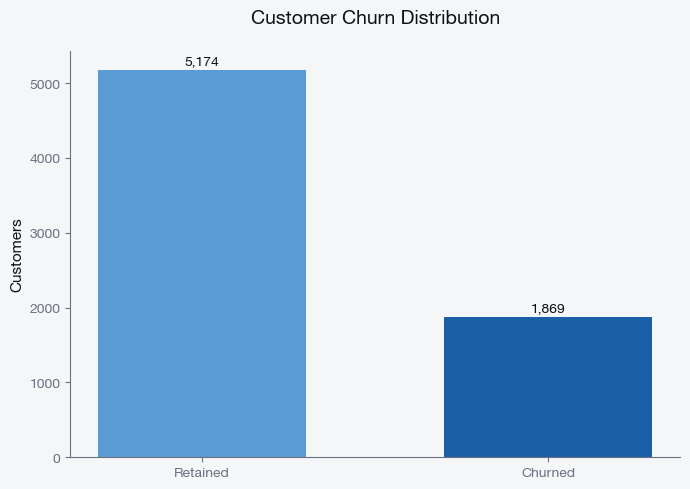


Churn rate: 26.5%


In [80]:
# Churn distribution
fig, ax = plt.subplots(figsize=(7, 5))

churn_counts = df['Churn'].value_counts()
bars = ax.bar(['Retained', 'Churned'], churn_counts.values, 
              color=[COLORS['secondary'], COLORS['primary']], width=0.6)

ax.set_ylabel('Customers')
ax.set_title('Customer Churn Distribution', fontweight='medium', pad=20)

for bar, count in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80, 
            f'{count:,}', ha='center', fontsize=10, color=COLORS['ink'])

plt.tight_layout()
plt.show()

print(f"\nChurn rate: {(df['Churn'] == 'Yes').mean():.1%}")

1,869 out of 7,043 customers churned. That's 26.5%, high enough to be a real business problem and enough churned examples for the model to learn from.

The class imbalance here (73/27 split) is also why I chose AUC over accuracy as the primary metric.

### Numeric Features vs Churn

Three continuous variables in the dataset: tenure, monthly charges, and total charges. 
I wanted to see if their distributions looked different between churned and retained customers.

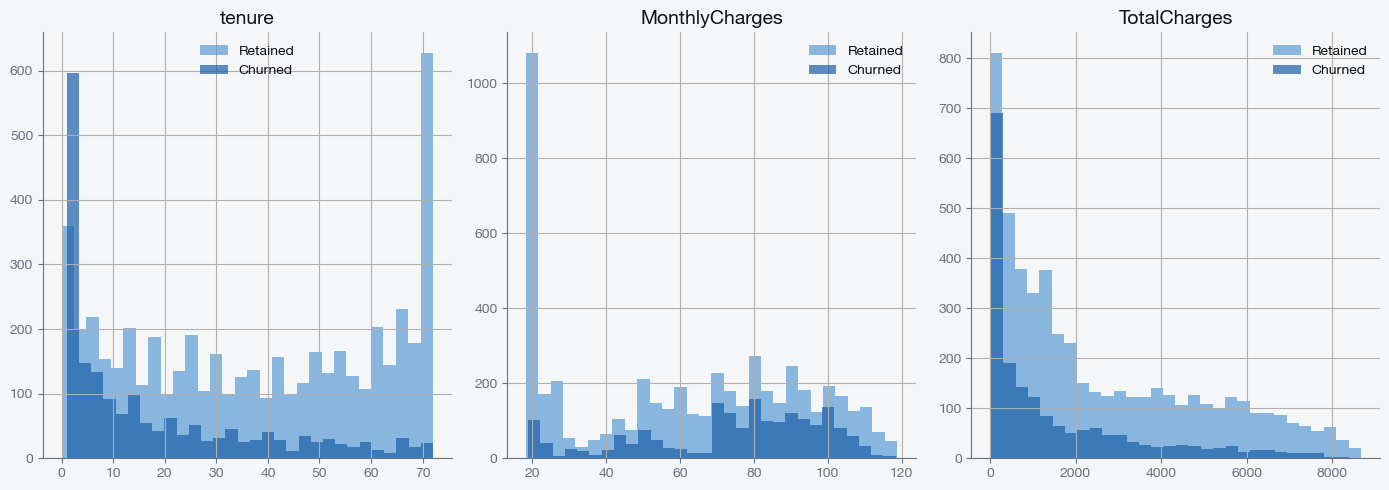

In [81]:
# Numeric features vs Churn
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, numeric_cols):
    df[df['Churn'] == 'No'][col].hist(ax=ax, bins=30, alpha=0.7, 
                                        color=COLORS['secondary'], label='Retained')
    df[df['Churn'] == 'Yes'][col].hist(ax=ax, bins=30, alpha=0.7, 
                                         color=COLORS['primary'], label='Churned')
    ax.set_title(col, fontweight='medium')
    ax.set_xlabel('')
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

Three things stand out here.

New customers churn the most, the churned bar spikes hard at 0-10 months tenure then drops off. Loyalty really does build over time.

Higher monthly charges correlate with churn. Customers paying $70-100/month leave more than those on lower plans. Possibly a value perception issue.

Total charges just reflects tenure, customers who leave early haven't accumulated much spend. Worth checking if it's redundant as a feature.

### Categorical Features vs Churn

Same idea but for the category columns: contract type, internet service, payment method, gender, senior citizen status.

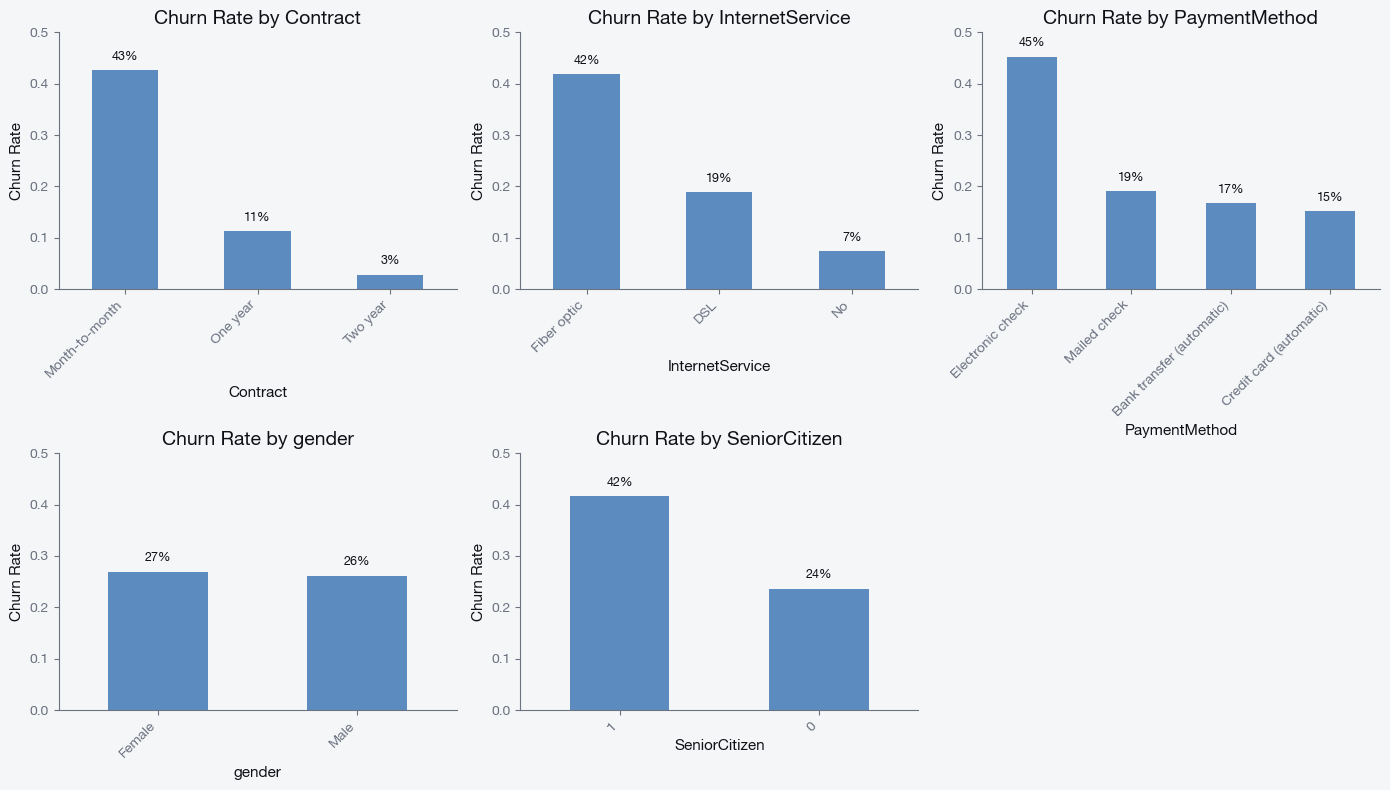

In [82]:
# Categorical features vs Churn
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender', 'SeniorCitizen']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.patch.set_facecolor(COLORS['background'])
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    ax.set_facecolor(COLORS['background'])
    
    # Calculate churn rate per category
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    churn_rate.sort_values(ascending=False).plot(kind='bar', ax=ax, color=COLORS['primary'], alpha=0.7)
    ax.set_title(f'Churn Rate by {col}', fontweight='medium')
    ax.set_ylabel('Churn Rate')
    ax.set_ylim(0, 0.5)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add percentage labels
    for i, v in enumerate(churn_rate.sort_values(ascending=False)):
        ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontsize=9, color=COLORS['ink'])

# Remove empty subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

Contract type is the clearest signal. Month-to-month customers churn at 43%, two-year customers at just 3%. The longer the commitment, the more likely they stay.

Fiber optic surprised me, 42% churn vs 19% for DSL. Fiber customers are probably paying more and expecting more. If the service doesn't deliver, they leave.

Electronic check stands out at 45% churn. The other payment methods sit between 15-19%. Not sure why this correlates so strongly, could be a proxy for something else like demographics or engagement level.

Gender is basically flat at 27% vs 26%. Not useful as a predictor.

Senior citizens churn at 42% vs 24% for non-seniors. Worth keeping as a feature.

## Feature Engineering

The EDA pointed to a few patterns worth capturing as explicit features.

I grouped tenure into buckets since the risk isn't linear, it drops off sharply after the first year. I also flagged customers on automatic payment, since manual payment methods like electronic check showed much higher churn.

In [83]:
# tenure buckets - new customers churn most
df['tenure_group'] = pd.cut(df['tenure'],
                            bins=[0, 12, 24, 48, 72],
                            labels=['0-1 yr', '1-2 yr', '2-4 yr', '4+ yr'])

# multiple services - more embedded = less likely to leave
df['has_multiple_services'] = ((df['PhoneService'] == 'Yes') & 
                               (df['InternetService'] != 'No')).astype(int)

# avg monthly spend - total charges / tenure (edge case: tenure=0)
df['avg_monthly_spend'] = df.apply(
    lambda x: x['MonthlyCharges'] if x['tenure'] == 0
    else x['TotalCharges'] / x['tenure'], axis=1)

# auto payment flag - manual payers churn more
df['auto_payment'] = df['PaymentMethod'].isin(
    ['Bank transfer (automatic)', 'Credit card (automatic)']).astype(int)

print("New features created:")
print(df[['tenure_group', 'has_multiple_services', 'avg_monthly_spend', 'auto_payment']].head(10))

New features created:
  tenure_group  has_multiple_services  avg_monthly_spend  auto_payment
0       0-1 yr                      0          29.850000             0
1       2-4 yr                      1          55.573529             0
2       0-1 yr                      1          54.075000             0
3       2-4 yr                      0          40.905556             1
4       0-1 yr                      1          75.825000             0
5       0-1 yr                      1         102.562500             0
6       1-2 yr                      1          88.609091             1
7       0-1 yr                      0          30.190000             0
8       2-4 yr                      1         108.787500             0
9        4+ yr                      1          56.257258             1


## Verify New Features vs Churn

Do the new features actually relate to churn? Quick check before moving to modelling.

In [84]:
print("Churn rate by tenure group:")
print(df.groupby('tenure_group', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean()).round(3))

print("\nChurn rate by multiple services:")
print(df.groupby('has_multiple_services', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean()).round(3))

print("\nChurn rate by auto-payment:")
print(df.groupby('auto_payment', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean()).round(3))

print("\nAvg monthly spend - Churned vs Retained:")
print(df.groupby('Churn', observed=True)['avg_monthly_spend'].mean().round(2))

Churn rate by tenure group:
tenure_group
0-1 yr    0.477
1-2 yr    0.287
2-4 yr    0.204
4+ yr     0.095
Name: Churn, dtype: float64

Churn rate by multiple services:
has_multiple_services
0    0.128
1    0.328
Name: Churn, dtype: float64

Churn rate by auto-payment:
auto_payment
0    0.347
1    0.160
Name: Churn, dtype: float64

Avg monthly spend - Churned vs Retained:
Churn
No     61.27
Yes    74.43
Name: avg_monthly_spend, dtype: float64


The features hold up.

Tenure group is the strongest signal - 47.7% churn in the first year dropping to 9.5% after four years. That's a 5x difference. New customers are genuinely at risk.

Multiple services cuts both ways — customers with both phone and internet churn at 32.8% vs 12.8% for single service customers. More services doesn't mean more loyalty here.

Auto-payment is a strong protective factor — manual payers churn at 34.7%, automatic payers at 16%. Set it and forget it customers are harder to lose.

Churned customers spend more on average — $74 vs $61/month. Higher spend, lower satisfaction. That's a service quality problem worth investigating.

## Data Preparation for Modelling

Splitting the data before encoding or scaling to avoid data leakage. 
Fit everything on training data only, then apply the same transformations to the test set.

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# define target and features
drop_cols = ['customerID', 'Churn', 'tenure_group']
X = df.drop(columns=drop_cols)
y = (df['Churn'] == 'Yes').astype(int)

# Split before transformations
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")
print(f"Train churn rate: {y_train.mean():.1%}")
print(f"Test churn rate: {y_test.mean():.1%}")

Train size: 5634
Test size: 1409
Train churn rate: 26.5%
Test churn rate: 26.5%


80/20 split, stratified so both sets have the same 26.5% churn rate. 
That's the `stratify=y` parameter — without it you could end up with an uneven churn distribution between train and test.

## Encode Categorical Variables

Models need numbers, not text. One-hot encoding for most categorical columns since there's no natural order between categories like payment method or internet service type.

In [86]:
# Get actual categorical columns (object type)
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode ({len(cat_cols)}):")
print(cat_cols)

Categorical columns to encode (15):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [87]:
# One-hot encode
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Ensure both have the same columns 
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"Features after encoding: {X_train_encoded.shape[1]}")
print(f"Sample columns: {X_train_encoded.columns.tolist()[:10]}")

Features after encoding: 33
Sample columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'has_multiple_services', 'avg_monthly_spend', 'auto_payment', 'gender_Male', 'Partner_Yes', 'Dependents_Yes']


15 categorical columns, 33 features after encoding. The `drop_first=True` drops one category per column to avoid multicollinearity.

The reindex line aligns test columns to match training columns exactly. Without it, any category that appears in test but not train would break the model.

## Scale Numeric Features

Tenure goes 0-72, monthly charges 18-118. Logistic regression is sensitive to scale, features with bigger ranges would dominate otherwise. Standardising puts everything on the same footing.

Fit the scaler on training data only, then apply to both. If you fit on all data you're leaking test information into training. That's data leakage.

In [88]:
# Identify numeric columns to scale
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend']

# Fit scaler on training data only
scaler = StandardScaler()
X_train_encoded[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])

# Apply same scaler to test data (transform only, not fit)
X_test_encoded[num_cols] = scaler.transform(X_test_encoded[num_cols])

print("Scaling complete.")
print(f"\nSample of scaled training data:")
print(X_train_encoded[num_cols].head())

Scaling complete.

Sample of scaled training data:
        tenure  MonthlyCharges  TotalCharges  avg_monthly_spend
3738  0.102371       -0.521976     -0.262257          -0.539986
3151 -0.711743        0.337478     -0.503635           0.391496
4860 -0.793155       -0.809013     -0.749883          -0.646102
3867 -0.263980        0.284384     -0.172722           0.276552
3810 -1.281624       -0.676279     -0.989374          -0.674608


StandardScaler transforms each value to a Z-score: 0 means average, negative means below average positive means above average. 
Tenure of -1.28 means that customer has been around significantly less than the average customer in the training set.

## Modelling

Data is ready. Time to build the model.

I went with Logistic Regression as the starting point: interpretable, works well with scaled data and SHAP explanations are clean and reliable with it.

In [89]:
# Check shape before modeling
print(f"Training features shape: {X_train_encoded.shape}")
print(f"Test features shape: {X_test_encoded.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test target shape: {y_test.shape}")

Training features shape: (5634, 33)
Test features shape: (1409, 33)
Training target shape: (5634,)
Test target shape: (1409,)


5,634 training rows, 1,409 test rows, 33 features each. Ready.

## Logistic Regression

I chose Logistic Regression over more complex models deliberately. It's interpretable, works well with scaled data and SHAP values are clean and reliable with linear models. If the business needs to explain why a customer was flagged, a logistic regression makes that conversation easier.

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score, roc_auc_score, confusion_matrix

# Train logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_encoded, y_train)

# Predict on test set
y_pred = log_reg.predict(X_test_encoded)
y_pred_proba = log_reg.predict_proba(X_test_encoded)[:, 1]  # Probability of class 1 (churn)

# Evaluate
print("Logistic Regression Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.3f}")

Logistic Regression Results:
Accuracy:  0.807
Precision: 0.660
Recall:    0.561
F1 Score:  0.607
ROC-AUC:   0.842


84.2% AUC. Solid. But recall at 56.1% means we're missing 44% of churners at the default threshold. At $2,100 per missed customer that's the real problem to solve.

The accuracy of 80.7% looks good but it's misleading, a model that predicts "no churn" for everyone would still hit 73%. AUC and recall are what matter here.

In [102]:
# cross-validation 
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(log_reg, X_train_encoded, y_train, cv=5, scoring='roc_auc')
print(f"CV AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

CV AUC: 0.845 (+/- 0.014)


CV AUC of 84.5% across 5 folds, standard deviation of 0.014. Stable. The test set result of 84.2% is consistent with cross-validation.

## Threshold Tuning

The default threshold is 0.5, if the model gives a customer more than 50% churn probability, it flags them. But that's arbitrary.

Missing a churner costs $2,100 in lost lifetime value. A false alarm costs around $100 in a wasted retention offer. The math says we should flag more aggressively and accept more false alarms to catch more real churners.

Lowering the threshold catches more churners at the cost of more false alarms. 
The question is where to draw the line.

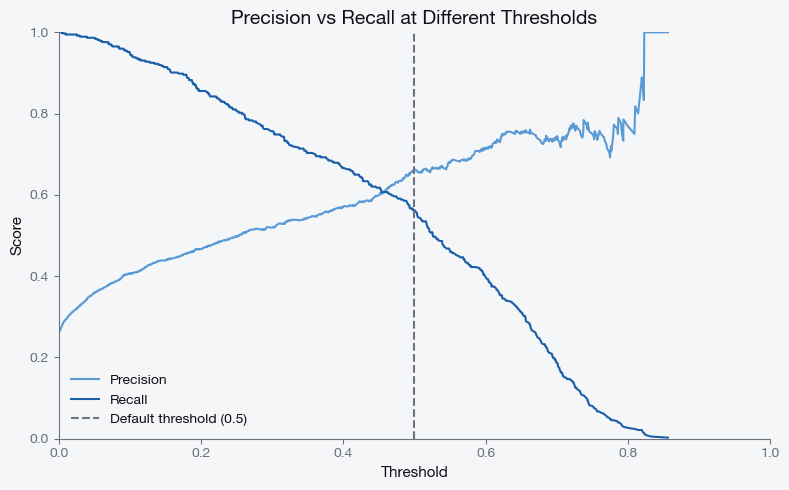

In [105]:
from sklearn.metrics import precision_recall_curve
 
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precision[:-1], label='Precision', color=COLORS['secondary'])
ax.plot(thresholds, recall[:-1], label='Recall', color=COLORS['primary'])
ax.axvline(x=0.5, color=COLORS['gray'], linestyle='--', label='Default threshold (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall at Different Thresholds', fontweight='medium')
ax.legend(frameon=False)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

Moving left on this chart increases recall but drops precision. 
At the default 0.5 threshold we catch 56% of churners. 
Moving left catches more, but flags more non churners too.

The question is where the business cost is minimised.

I assigned costs to each outcome based on the CLV calculation earlier:
- Miss a churner: $2,100 lost
- False alarm: $100 wasted offer
- Catch a churner: $100 offer cost but customer saved

Then ran the model at every threshold from 0.1 to 0.9 and calculated total cost.

In [95]:
# cost assumptions: miss = $2100 (CLV), false alarm = $100, catch = $100, correct pass = $0

cost_fn = 2100  # False Negative: missed churner
cost_fp = 100   # False Positive: unnecessary retention offer
cost_tp = 100   # True Positive: retention offer cost (but we keep customer)
cost_tn = 0     # True Negative: no cost

# Calculate total cost at each threshold
thresholds_to_test = np.arange(0.1, 0.9, 0.05)
costs = []

for thresh in thresholds_to_test:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    
    tn = ((y_pred_thresh == 0) & (y_test == 0)).sum()
    fp = ((y_pred_thresh == 1) & (y_test == 0)).sum()
    fn = ((y_pred_thresh == 0) & (y_test == 1)).sum()
    tp = ((y_pred_thresh == 1) & (y_test == 1)).sum()
    
    total_cost = (fn * cost_fn) + (fp * cost_fp) + (tp * cost_tp) + (tn * cost_tn)
    costs.append(total_cost)

# Find optimal threshold
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds_to_test[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"Minimum total cost: ${costs[optimal_idx]:,.0f}")

Optimal threshold: 0.10
Minimum total cost: $127,200


Optimal threshold: 0.1. Total cost drops to $127,200 vs $785,400 doing nothing.

0.1 is aggressive, it flags almost everyone with any churn signal. 
But given the cost asymmetry, that's the right call.

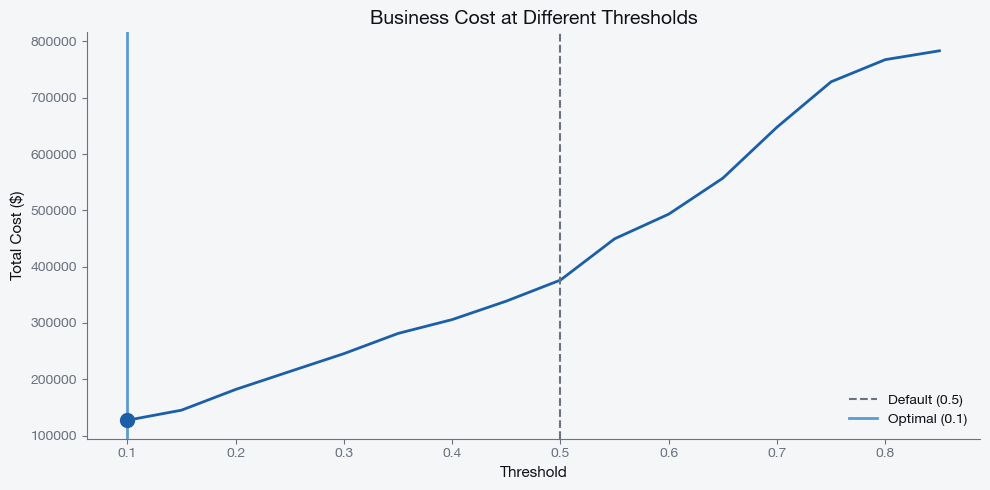


--- Comparison ---

Default threshold (0.5):
Recall: 56.1%
Precision: 66.0%
Churners caught: 210 out of 374

Optimal threshold (0.1):
Recall: 94.9%
Precision: 40.7%
Churners caught: 355 out of 374


In [106]:
# Compare results at different thresholds
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds_to_test, costs, color=COLORS['primary'], linewidth=2)
ax.axvline(x=0.5, color=COLORS['gray'], linestyle='--', label='Default (0.5)')
ax.axvline(x=optimal_threshold, color=COLORS['secondary'], linestyle='-', linewidth=2, label=f'Optimal ({optimal_threshold})')
ax.scatter([optimal_threshold], [costs[optimal_idx]], color=COLORS['primary'], s=100, zorder=5)

ax.set_xlabel('Threshold')
ax.set_ylabel('Total Cost ($)')
ax.set_title('Business Cost at Different Thresholds', fontweight='medium')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

# Show metrics at both thresholds
print("\n--- Comparison ---")
print(f"\nDefault threshold (0.5):")
y_pred_default = (y_pred_proba >= 0.5).astype(int)
print(f"Recall: {recall_score(y_test, y_pred_default):.1%}")
print(f"Precision: {precision_score(y_test, y_pred_default):.1%}")
print(f"Churners caught: {y_pred_default[y_test == 1].sum()} out of {y_test.sum()}")

print(f"\nOptimal threshold ({optimal_threshold}):")
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
print(f"Recall: {recall_score(y_test, y_pred_optimal):.1%}")
print(f"Precision: {precision_score(y_test, y_pred_optimal):.1%}")
print(f"Churners caught: {y_pred_optimal[y_test == 1].sum()} out of {y_test.sum()}")

355 out of 374 churners caught at threshold 0.1. That's the 56% to 95% improvement.

Precision drops to 40.7%, meaning 6 in 10 flagged customers won't actually churn. 
That's where the tiered intervention strategy comes in. You don't treat all flagged customers the same way.

### Threshold Tuning Results

| Metric | Default (0.5) | Optimal (0.1) |
|--------|---------------|---------------|
| Recall | 56.1% | 94.9% |
| Precision | 66.0% | 40.7% |
| Churners caught | 210 / 374 | 355 / 374 |
| Churners missed | 164 | 19 |

145 additional churners caught by moving from 0.5 to 0.1. 
At $2,100 CLV each, that's the math behind the $658K figure.

### Cost Matrix

| Prediction | Actual | Outcome | Cost |
|------------|--------|---------|------|
| Churn | Churn | **True Positive** - We intervene, customer stays | $100 (retention offer) |
| No Churn | No Churn | **True Negative** - No action needed | $0 |
| Churn | No Churn | **False Positive** - Wasted retention offer | $100 |
| No Churn | Churn | **False Negative** - Missed churner, customer leaves | $2,100 (lost CLV) |

A false negative costs 21x more than a false positive. 
That's why 0.1 makes sense despite the low precision.

### Cost Assumptions 

The $2,100 CLV and $100 retention offer are assumptions based on the dataset averages. 
In a real deployment these would come from the finance and marketing teams. 
The 100% intervention success rate is the biggest simplification, in practice you'd measure this through A/B testing.

| Parameter | Assumed Value | Real-World Source |
|-----------|---------------|-------------------|
| Customer Lifetime Value | $2,100 | Finance team |
| Retention offer cost | $100 | Marketing budget |
| Intervention success rate | 100% (assumed) | A/B test results |



In [97]:
# Full cost breakdown at optimal threshold
threshold = 0.1
y_pred_optimal = (y_pred_proba >= threshold).astype(int)

# Calculate confusion matrix values
tn = ((y_pred_optimal == 0) & (y_test == 0)).sum()
fp = ((y_pred_optimal == 1) & (y_test == 0)).sum()
fn = ((y_pred_optimal == 0) & (y_test == 1)).sum()
tp = ((y_pred_optimal == 1) & (y_test == 1)).sum()

# Cost calculation
cost_tp = tp * 100    # Retention offer cost
cost_fp = fp * 100    # Wasted retention offer
cost_fn = fn * 2100   # Lost customer
cost_tn = tn * 0      # No cost

total_cost = cost_tp + cost_fp + cost_fn + cost_tn

print("Cost Breakdown at Optimal Threshold (0.1):")
print(f"  True Positives:  {tp:,} x $100  = ${cost_tp:,}")
print(f"  False Positives: {fp:,} x $100  = ${cost_fp:,}")
print(f"  False Negatives: {fn:,} x $2,100 = ${cost_fn:,}")
print(f"  True Negatives:  {tn:,} x $0    = ${cost_tn:,}")
print(f"\nTotal intervention cost: ${total_cost:,}")

# Compare to doing nothing
do_nothing_cost = (y_test == 1).sum() * 2100
print(f"\nCost of doing nothing (lose all churners): ${do_nothing_cost:,}")
print(f"Net savings from model: ${do_nothing_cost - total_cost:,}")

Cost Breakdown at Optimal Threshold (0.1):
  True Positives:  355 x $100  = $35,500
  False Positives: 518 x $100  = $51,800
  False Negatives: 19 x $2,100 = $39,900
  True Negatives:  517 x $0    = $0

Total intervention cost: $127,200

Cost of doing nothing (lose all churners): $785,400
Net savings from model: $658,200


### Full Cost Analysis (Test Set: 1,409 Customers)

| Outcome | Count | Cost Each | Total |
|---------|-------|-----------|-------|
| True Positives (saved churners) | 355 | $100 | $35,500 |
| False Positives (wasted offers) | 518 | $100 | $51,800 |
| False Negatives (missed churners) | 19 | $2,100 | $39,900 |
| True Negatives | 517 | $0 | $0 |
| **Total cost with model** | | | **$127,200** |

That's where the $658K comes from. $785,400 doing nothing, $127,200 with the model. 
The difference is $658,200.

The $3.3M scaled figure assumes the same model performance across all 7,043 customers and 100% intervention success. Both are optimistic. Treat it as a ceiling, not a forecast.

## SHAP Analysis

SHAP (SHapley Additive exPlanations) answers the question the model alone can't: why did it flag this customer?

Without explainability, you have a black box. You can't tell a retention team "call this customer" without being able to say why. SHAP makes the model's reasoning visible, both overall patterns and individual customer explanations.

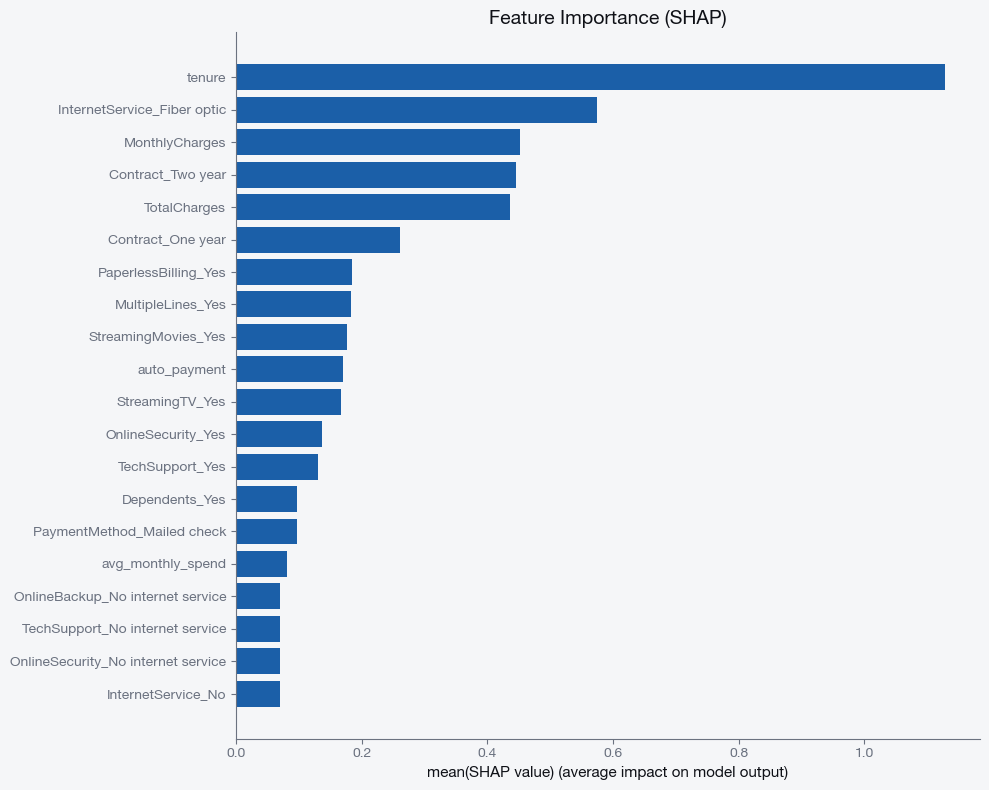

In [98]:
import shap

# Create SHAP for logistic regression
explainer = shap.LinearExplainer(log_reg, X_train_encoded)

# Calculate SHAP for test set
shap_values = explainer.shap_values(X_test_encoded)

plt.figure(figsize=(10, 8))
plt.barh(range(20), 
         np.abs(shap_values).mean(axis=0)[np.argsort(np.abs(shap_values).mean(axis=0))[-20:]], 
         color=COLORS['primary'])
plt.yticks(range(20), 
           X_test_encoded.columns[np.argsort(np.abs(shap_values).mean(axis=0))[-20:]])
plt.xlabel('mean(SHAP value) (average impact on model output)')
plt.title('Feature Importance (SHAP)', fontweight='medium')
plt.gca().set_facecolor(COLORS['background'])
plt.gcf().set_facecolor(COLORS['background'])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Tenure dominates everything else by a wide margin. The gap between tenure (1.13) and the next feature, fiber optic (0.58), is almost double. How long someone has been a customer is the single strongest signal.

Fiber optic showing up as #2 is interesting. It's not the internet service itself causing churn, it's likely a service quality or pricing expectation issue. Worth investigating separately.

TotalCharges at #5 is probably just a proxy for tenure. Longer customers have higher total charges. The model is seeing the same signal twice.

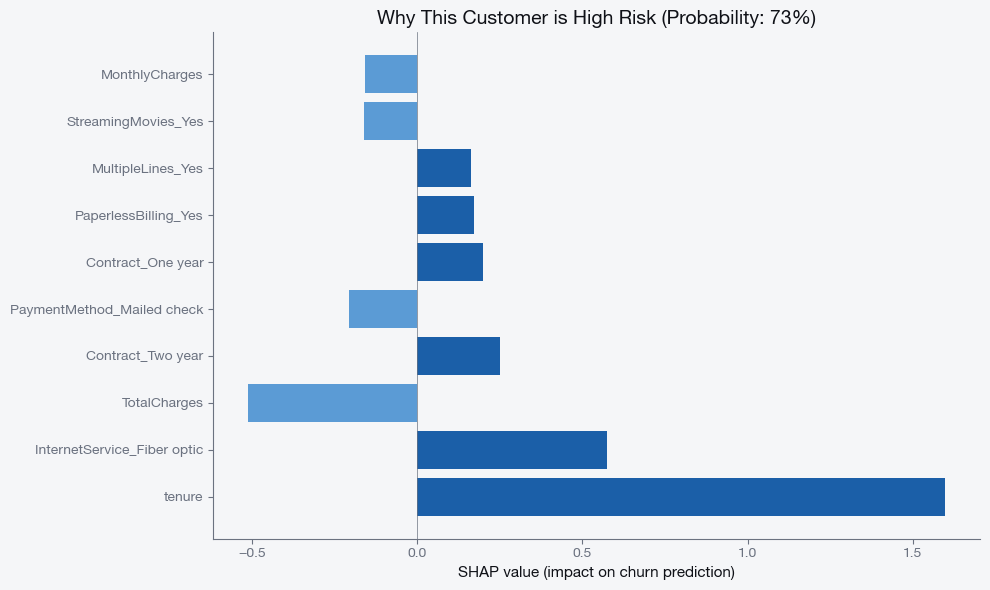


Actual outcome: Churned


In [99]:
# Individual customer explanation
high_risk_idx = np.where(y_pred_proba >= 0.7)[0][0]

# Get SHAP values for this customer
customer_shap = shap_values[high_risk_idx]
feature_names = X_test_encoded.columns.tolist()

# Get top 10 factors 
top_idx = np.argsort(np.abs(customer_shap))[::-1][:10]
top_features = [feature_names[i] for i in top_idx]
top_values = [customer_shap[i] for i in top_idx]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(COLORS['background'])
ax.set_facecolor(COLORS['background'])

colors = [COLORS['primary'] if v > 0 else COLORS['secondary'] for v in top_values]
ax.barh(range(len(top_features)), top_values, color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features)
ax.axvline(x=0, color=COLORS['gray'], linewidth=0.5)
ax.set_xlabel('SHAP value (impact on churn prediction)')
ax.set_title(f'Why This Customer is High Risk (Probability: {y_pred_proba[high_risk_idx]:.0%})', fontweight='medium')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nActual outcome: {'Churned' if y_test.iloc[high_risk_idx] == 1 else 'Retained'}")

## Individual Customer Explanation

Global SHAP shows overall patterns. This shows why the model flagged one specific high-risk customer with probability ≥ 70%.

The model was right. 73% predicted probability, actually churned.

Tenure is driving almost everything here at 1.6. This customer is new. Fiber optic adds to the risk. TotalCharges going left makes sense: new customer, low total spend so far, which actually reduces the signal slightly.

## Risk Segmentation & Intervention Strategy

Flagging customers is only half the job. The other half is knowing what to do with them.

In [100]:
# Create risk segments based on churn probability
df_test = X_test_encoded.copy()
df_test['churn_probability'] = y_pred_proba
df_test['actual_churn'] = y_test.values

# Define risk tiers
def assign_risk_tier(prob):
    if prob >= 0.7:
        return 'Critical'
    elif prob >= 0.4:
        return 'High'
    elif prob >= 0.2:
        return 'Medium'
    else:
        return 'Low'

df_test['risk_tier'] = df_test['churn_probability'].apply(assign_risk_tier)

# Count customers in each tier with pct
total = len(df_test)
tier_counts = df_test['risk_tier'].value_counts().sort_index()

print("Customer Risk Distribution:")
for tier in ['Critical', 'High', 'Low', 'Medium']:
    count = tier_counts[tier]
    pct = count / total * 100
    print(f"  {tier:10} {count:5} ({pct:.0f}%)")

print(f"\n  Total: {total}")

print("\nChurn rate by tier:")
print(df_test.groupby('risk_tier')['actual_churn'].mean().round(3).sort_index())

Customer Risk Distribution:
  Critical      94 (7%)
  High         341 (24%)
  Low          724 (51%)
  Medium       250 (18%)

  Total: 1409

Churn rate by tier:
risk_tier
Critical    0.745
High        0.525
Low         0.075
Medium      0.284
Name: actual_churn, dtype: float64


The segmentation validates. Critical tier (≥70% probability) has 74.5% actual churn. 
Low tier (<20% probability) has 7.5% actual churn. The model is ranking risk correctly.

94 customers need immediate attention. That's a manageable number for a personal outreach campaign.

### Risk Segmentation & Recommended Interventions

| Risk Tier | Probability | Customers | % of Total | Actual Churn | Priority | Recommended Action |
|-----------|-------------|-----------|------------|--------------|----------|-------------------|
| **Critical** | ≥70% | 94 | 7% | 74.5% | Immediate | Personal call + contract upgrade offer |
| **High** | 40-70% | 341 | 24% | 52.5% | High | Proactive outreach + loyalty discount |
| **Medium** | 20-40% | 250 | 18% | 28.4% | Moderate | Email campaign + service quality check |
| **Low** | <20% | 724 | 51% | 7.5% | Monitor | No intervention needed |


## Top 10 Highest Risk Customers

This is what the model produces as an actionable output: a ranked list with churn probability, risk tier, the top drivers for each customer and a recommended action.

This is what a retention team would actually work from.

In [101]:
# top 10 highest risk customers with their key churn drivers
top_risk_idx = np.argsort(y_pred_proba)[::-1][:10]

print("=" * 80)
print("CUSTOMER CHURN RISK REPORT - TOP 10 HIGHEST RISK CUSTOMERS")
print("=" * 80)

for i, idx in enumerate(top_risk_idx):
    prob = y_pred_proba[idx]
    
    # Get top 3 drivers for this customer
    customer_shap = shap_values[idx]
    top_drivers_idx = np.argsort(customer_shap)[::-1][:3]
    drivers = [X_test_encoded.columns[j] for j in top_drivers_idx]
    
    print(f"\n{i+1}. Customer #{idx}")
    print(f"   Churn Probability: {prob:.0%}")
    print(f"   Risk Tier: {'Critical' if prob >= 0.7 else 'High' if prob >= 0.4 else 'Medium'}")
    print(f"   Top Risk Factors: {', '.join(drivers)}")
    print(f"   Recommended Action: {'Immediate personal outreach' if prob >= 0.7 else 'Proactive retention campaign'}")

CUSTOMER CHURN RISK REPORT - TOP 10 HIGHEST RISK CUSTOMERS

1. Customer #1090
   Churn Probability: 86%
   Risk Tier: Critical
   Top Risk Factors: tenure, InternetService_Fiber optic, Contract_Two year
   Recommended Action: Immediate personal outreach

2. Customer #1221
   Churn Probability: 83%
   Risk Tier: Critical
   Top Risk Factors: tenure, InternetService_Fiber optic, Contract_Two year
   Recommended Action: Immediate personal outreach

3. Customer #1175
   Churn Probability: 83%
   Risk Tier: Critical
   Top Risk Factors: tenure, InternetService_Fiber optic, Contract_Two year
   Recommended Action: Immediate personal outreach

4. Customer #1164
   Churn Probability: 82%
   Risk Tier: Critical
   Top Risk Factors: tenure, InternetService_Fiber optic, Contract_Two year
   Recommended Action: Immediate personal outreach

5. Customer #647
   Churn Probability: 82%
   Risk Tier: Critical
   Top Risk Factors: tenure, InternetService_Fiber optic, Contract_Two year
   Recommended Act

## Conclusion

The model works. 84% AUC, 95% recall at threshold 0.1, and a clear framework for who to contact and why.

The most important finding: tenure dominates everything. The first year is when customers decide whether to stay. That's where retention effort should focus.

The code is fully reproducible. Everything runs from the public dataset with no local dependencies.

If I were handing this to a business team, the output is already there: 1,409 customers ranked by risk, with the top drivers for each one and a recommended action. The next step would be A/B testing the interventions to measure what actually works and replacing the cost assumptions with real numbers from finance and marketing.